<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/Logistic_Examples_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pregress

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pregress as pr
import numpy as np

# Load in and observe the Employee Churn data

In [ ]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRv_f7yQDN27AGdjsTsT2p6K1rR4Pb7zmJ4oVtA7BRR2Sj7C_ucVCs-9501OvQFY1Wwl0ijax8s03UT/pub?gid=942741297&single=true&output=csv")
df.head()

,Salary,Churn
0,78.363,1
1,99.317,0
2,61.671,1
3,84.816,0
4,72.579,1


# Plot a Scatterplot of Churn vs. Salary

In [ ]:
pr.plots("Churn ~ Salary", data = df)

The plots function is for multiple predictor variables.


# Fit an OLS Model

In [ ]:
model = pr.fit("Churn ~ Salary", data = df)

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Churn   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     517.8
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.54e-93
Time:                        15:33:01   Log-Likelihood:                -512.41
No. Observations:                1055   AIC:                             1029.
Df Residuals:                    1053   BIC:                             1039.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9426      0.071     27.535      0.000       1.804       2.081
Salary        -0.0203      0.001    -22.754      0.000      -0.022      -0.019
==============================================================================
Omnibus:                       81.438   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.475
Skew:                           0.088   Prob(JB):                     6.56e-07
Kurtosis:                       2.215   Cond. No.                         460.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Plot the Scatterplot with the Regression Line

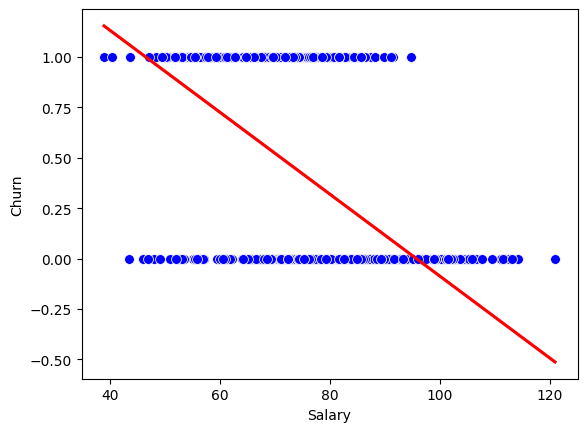

In [ ]:
pr.plot_xy('Churn ~ Salary', data = df, model = 'line')

# Get a Barplot of the Salary Means for Each Class




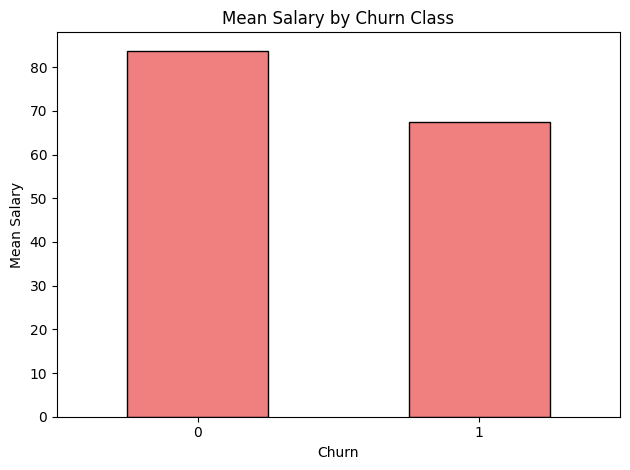

In [ ]:
import matplotlib.pyplot as plt
mean_salary = df.groupby('Churn')['Salary'].mean()
mean_salary.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Mean Salary by Churn Class')
plt.xlabel('Churn')
plt.ylabel('Mean Salary')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


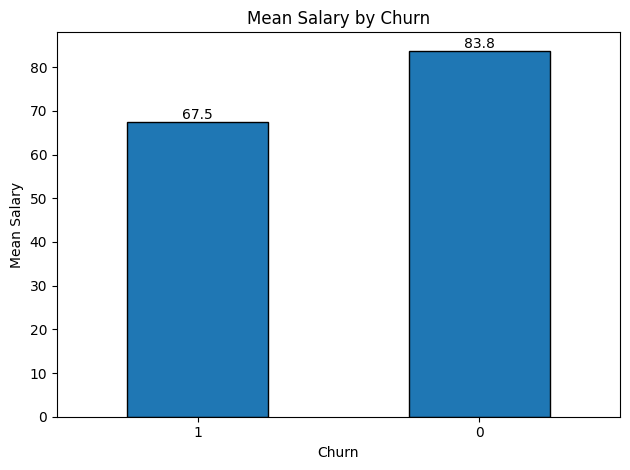

In [ ]:
import matplotlib.pyplot as plt

col = 'Churn'

means = (df.groupby(col, observed=True, dropna=False)['Salary'].mean().sort_values())

ax = means.plot(kind='bar', edgecolor='black')
ax.set_title('Mean Salary by ' + col)
ax.set_xlabel(col)
ax.set_ylabel('Mean Salary')
ax.bar_label(ax.containers[0], fmt='%.1f')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Fit a Logistic Model

---



In [ ]:
model2 = pr.fit("Churn ~ Salary", data=df, method="logistic")
pr.summary(model2)

Summary of Logistic Regression Analysis:

Coefficients (Odds Ratios):
------------------------------------------------------
             coef  std err       z  P>|z|
Intercept  9.4313    0.635  14.845    0.0
Salary    -0.1327    0.009 -15.548    0.0

Model Statistics:
------------------------------------------------------
Log-Likelihood: -479.5036            AIC: 963.0071
Pseudo R-squared: 0.3291         BIC: -6371.2376


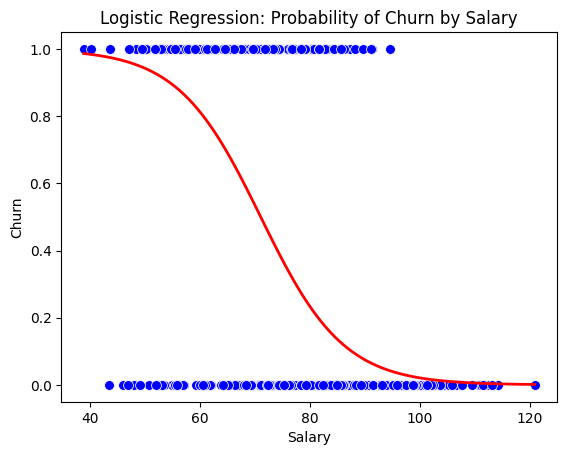

In [ ]:
pred = pr.predict(model)
df['Predicted_Prob'] = pred
pr.plot_xy("Churn ~ Salary", data=df, model=model, pcolor='blue', lcolor='red',
           title="Logistic Regression: Probability of Churn by Salary")


# Plot a Scatterplot with a Logistic Curve

 # Histogram of Churn Probabilities

In [ ]:
df['Churn_Prob'] = pr.predict(model)

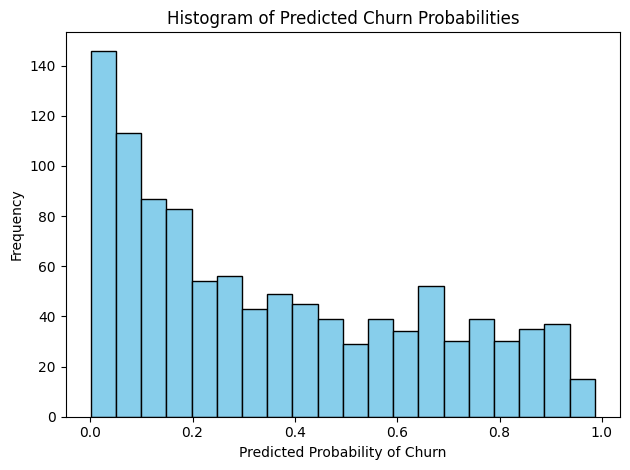

In [ ]:
plt.hist(df['Churn_Prob'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Predicted Churn Probabilities')
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

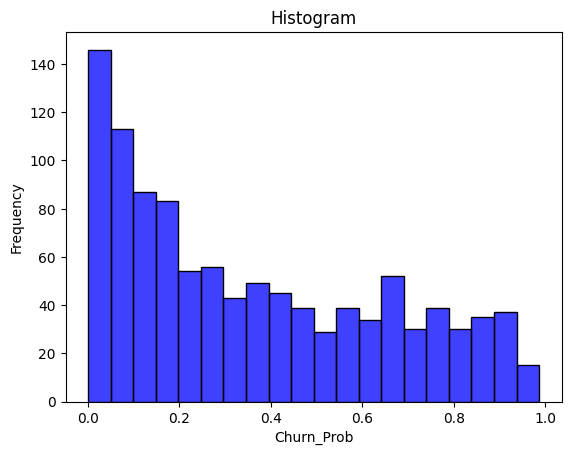

In [ ]:
pr.hist(df['Churn_Prob'], bins=20)

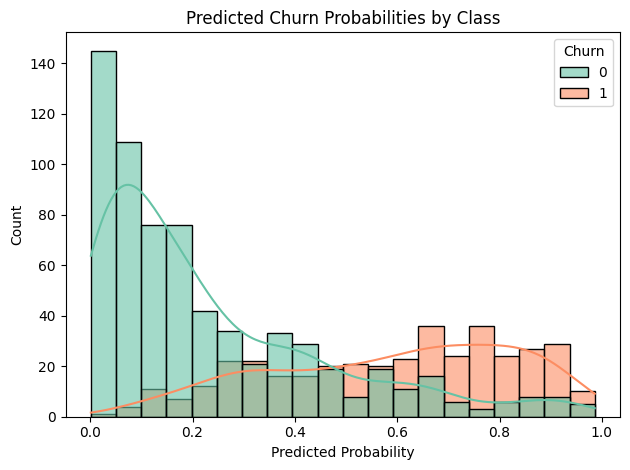

In [ ]:
import seaborn as sns

sns.histplot(data=df, x='Churn_Prob', hue='Churn', bins=20, kde=True, palette='Set2', alpha=0.6)
plt.title('Predicted Churn Probabilities by Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# Vacation Purchases

https://docs.google.com/spreadsheets/d/e/2PACX-1vQIjwUkXH8sxyGC1sS-UMgyFPmUMPkdiy96u52eHb3ffWlxAuot1i4QddpUEi1de_9bRXrG9yHgCZRK/pub?gid=2082650642&single=true&output=csv

In [ ]:
vacation_data = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQIjwUkXH8sxyGC1sS-UMgyFPmUMPkdiy96u52eHb3ffWlxAuot1i4QddpUEi1de_9bRXrG9yHgCZRK/pub?gid=2082650642&single=true&output=csv')
print(vacation_data.head())

    Price  Age  Purchased
0  673.24   64          0
1  944.91   43          0
2  702.97   69          0
3  823.68   47          0
4  319.73   71          1


# Fit a Logistic Model

In [ ]:
mode3l = pr.fit("Purchased ~ Price + Age", data=vacation_data, method="logistic")
print(mode3l.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:              Purchased   No. Observations:                  277
Model:                            GLM   Df Residuals:                      274
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38.730
Date:                Thu, 23 Oct 2025   Deviance:                       77.460
Time:                        15:48:46   Pearson chi2:                     437.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6657
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.8206      3.190      5.586      0.0

In [ ]:
pr.summary(mode3l)

Summary of Logistic Regression Analysis:

Coefficients (Odds Ratios):
------------------------------------------------------
              coef  std err      z  P>|z|
Intercept  17.8206    3.190  5.586  0.000
Price      -0.0388    0.006 -6.251  0.000
Age         0.0267    0.020  1.317  0.188

Model Statistics:
------------------------------------------------------
Log-Likelihood: -38.7298            AIC: 83.4596
Pseudo R-squared: 0.6657         BIC: -1463.5212


In [ ]:
pr.summary(model, out='statsmodels')

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 1055
Model:                            GLM   Df Residuals:                     1053
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -479.50
Date:                Thu, 23 Oct 2025   Deviance:                       959.01
Time:                        15:51:17   Pearson chi2:                 1.04e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3291
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.4313      0.635     14.845      0.0

# Predict the Log-odds for a 44 year-old with a Price of 500

In [ ]:
new_data = pd.DataFrame({'Price': [500], 'Age': [44]})
log_odds = pr.predict(mode3l, newX=new_data)
print("Predicted log-odds:", log_odds[0])

Predicted log-odds: 0.402487338642816





# Calculate the Probability that someone Buys (44 year-old with Price=500)

In [ ]:
prob = 1 / (1 + np.exp(-log_odds))
print("Predicted probability of purchase:", prob[0])


Predicted probability of purchase: 0.5992851229826621


# Calculate the Accuracy with 50% Threshold




In [ ]:
vacation_data['Predicted_Prob'] = pr.predict(mode3l)
vacation_data['Predicted_Class'] = (vacation_data['Predicted_Prob'] >= 0.5).astype(int)

accuracy = (vacation_data['Predicted_Class'] == vacation_data['Purchased']).mean()
print(f"Model Accuracy (50% threshold): {accuracy:.2f}")

Model Accuracy (50% threshold): 0.95


# Find the Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(vacation_data['Purchased'], vacation_data['Predicted_Class'])
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[145   8]
 [  7 117]]


# Plot the ROC Curve



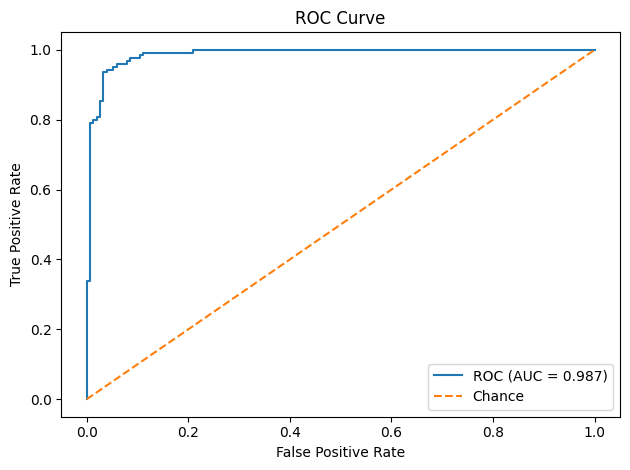

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1) Get scores from your fitted pregress logistic model
#    If pr.predict(model) returns log-odds (linear predictor), convert to probability.
log_odds = pr.predict(mode3l)
probs = 1 / (1 + np.exp(-log_odds))   # sigmoid

y_true = vacation_data['Purchased'].to_numpy()

# 2) ROC points and AUC
fpr, tpr, thresholds = roc_curve(y_true, probs)
auc = roc_auc_score(y_true, probs)

# 3) Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Calculate the AUC

In [ ]:
vacation_data['Predicted_Prob'] = pr.predict(mode3l)
auc = roc_auc_score(vacation_data['Purchased'], vacation_data['Predicted_Prob'])
print(f"AUC (Area Under the Curve): {auc:.3f}")

AUC (Area Under the Curve): 0.987
